In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
df = sns.load_dataset('titanic')

In [43]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [45]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [46]:
df['sex'].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

In [47]:
df['sex']. value_counts(normalize=True)

sex
male      0.647587
female    0.352413
Name: proportion, dtype: float64

In [48]:
df['embarked'].value_counts()

embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [49]:
df = df.drop(columns=[
    "alive",
    "deck",
    "class",
    "who",
    "adult_male",
    "embark_town",
    "alone"
])

In [50]:
df['age'] = df['age'].fillna(df['age'].mean())

In [51]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [52]:
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

In [53]:
df.select_dtypes(include="object").head()

,sex,embarked
0,male,S
1,female,C
2,female,S
3,female,S
4,male,S


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       891 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [55]:
df['sex'] = df['sex'].map({
    "male": 1,
    "female":2
})

In [56]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,1,22.0,1,0,7.2500,S
1,1,1,2,38.0,1,0,71.2833,C
2,1,3,2,26.0,0,0,7.9250,S
3,1,1,2,35.0,1,0,53.1000,S
4,0,3,1,35.0,0,0,8.0500,S


In [57]:
df = pd.get_dummies(df, columns=['embarked'], drop_first=True)

In [58]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked_Q,embarked_S
0,0,3,1,22.0,1,0,7.2500,False,True
1,1,1,2,38.0,1,0,71.2833,False,False
2,1,3,2,26.0,0,0,7.9250,False,True
3,1,1,2,35.0,1,0,53.1000,False,True
4,0,3,1,35.0,0,0,8.0500,False,True


In [59]:
X = df.drop("survived", axis=1)
y = df['survived']

In [60]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [61]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [62]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [63]:
y_pred_before = model.predict(X_test)

In [64]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, roc_auc_score, roc_curve

print(accuracy_score(y_test, y_pred_before))
print(precision_score(y_test, y_pred_before))
print(recall_score(y_test, y_pred_before))

y_proba_before = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba_before)

roc_score_value= roc_auc_score(y_test, y_pred_before)
print(roc_score_value)

0.8100558659217877
0.7857142857142857
0.7432432432432432
0.8001930501930502


In [65]:
import numpy as np

best_idx = np.argmax(tpr - fpr)

best_threshold = thresholds[best_idx]

print(best_threshold)

0.3463442470677359


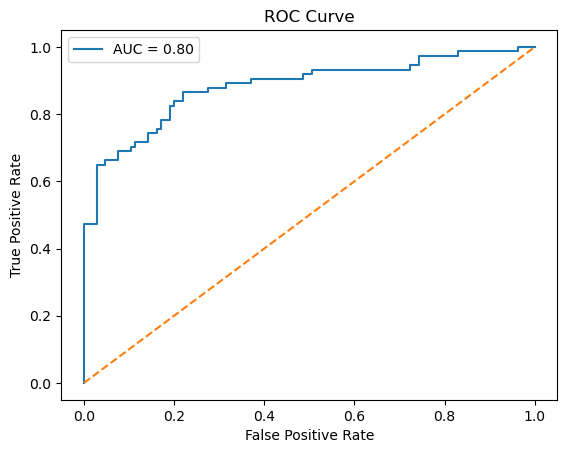

In [66]:
import matplotlib.pyplot as plt

plt.plot(fpr, tpr, label=f"AUC = {roc_score_value:.2f}")
plt.plot([0,1],[0,1],"--")   # Random classifier
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## After Feature Engineering

In [67]:
df["familySize"] = df['sibsp'] + df['parch'] + 1

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked_Q,embarked_S,familySize
0,0,3,1,22.0,1,0,7.2500,False,True,2
1,1,1,2,38.0,1,0,71.2833,False,False,2
2,1,3,2,26.0,0,0,7.9250,False,True,1
3,1,1,2,35.0,1,0,53.1000,False,True,2
4,0,3,1,35.0,0,0,8.0500,False,True,1


In [68]:
df['isAlone'] = (df['familySize'] ==1).astype(int)

df['ageGroup'] = pd.cut(df['age'], bins=[0,18,40,60,100], labels=['child', 'adult', 'middle', 'senior'])

In [69]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked_Q,embarked_S,familySize,isAlone,ageGroup
0,0,3,1,22.0,1,0,7.2500,False,True,2,0,adult
1,1,1,2,38.0,1,0,71.2833,False,False,2,0,adult
2,1,3,2,26.0,0,0,7.9250,False,True,1,1,adult
3,1,1,2,35.0,1,0,53.1000,False,True,2,0,adult
4,0,3,1,35.0,0,0,8.0500,False,True,1,1,adult


In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   survived    891 non-null    int64   
 1   pclass      891 non-null    int64   
 2   sex         891 non-null    int64   
 3   age         891 non-null    float64 
 4   sibsp       891 non-null    int64   
 5   parch       891 non-null    int64   
 6   fare        891 non-null    float64 
 7   embarked_Q  891 non-null    bool    
 8   embarked_S  891 non-null    bool    
 9   familySize  891 non-null    int64   
 10  isAlone     891 non-null    int32   
 11  ageGroup    891 non-null    category
dtypes: bool(2), category(1), float64(2), int32(1), int64(6)
memory usage: 62.1 KB


In [71]:
df = pd.get_dummies(df, columns=['ageGroup'], drop_first=True)

In [72]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked_Q,embarked_S,familySize,isAlone,ageGroup_adult,ageGroup_middle,ageGroup_senior
0,0,3,1,22.0,1,0,7.2500,False,True,2,0,True,False,False
1,1,1,2,38.0,1,0,71.2833,False,False,2,0,True,False,False
2,1,3,2,26.0,0,0,7.9250,False,True,1,1,True,False,False
3,1,1,2,35.0,1,0,53.1000,False,True,2,0,True,False,False
4,0,3,1,35.0,0,0,8.0500,False,True,1,1,True,False,False


In [73]:
X= df.drop('survived', axis=1)
y= df['survived']

In [74]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [75]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [76]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [77]:
y_pred_after = model.predict(X_test)

In [78]:
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

print(accuracy_score(y_test, y_pred_after))
print(roc_auc_score(y_test, y_pred_after))

y_proba_after = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba_after)


### best threshold selection

best_idx = np.argmax(tpr-fpr)

best_threshold = thresholds[best_idx]

print(f'Best Threshold: {best_threshold}')


0.8044692737430168
0.7934362934362935
Best Threshold: 0.3671608902440717


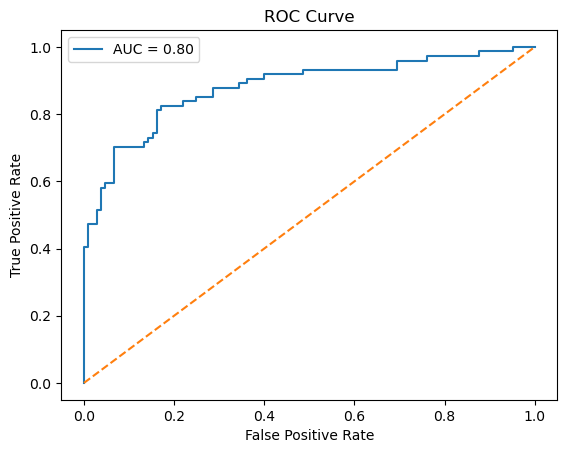

In [79]:
import matplotlib.pyplot as plt

plt.plot(fpr, tpr, label=f"AUC = {roc_score_value:.2f}")
plt.plot([0,1],[0,1],"--")   # Random classifier
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Model Comparison

In [80]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import pandas as pd

comparison = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],

    "Before Feature Engineering":[
        accuracy_score(y_test,y_pred_before),
        precision_score(y_test,y_pred_before),
        recall_score(y_test,y_pred_before),
        f1_score(y_test,y_pred_before),
        roc_auc_score(y_test,y_proba_before)
    ],

    "After Feature Engineering":[
        accuracy_score(y_test,y_pred_after),
        precision_score(y_test,y_pred_after),
        recall_score(y_test,y_pred_after),
        f1_score(y_test,y_pred_after),
        roc_auc_score(y_test,y_proba_after)
    ]
})

comparison

,Metric,Before Feature Engineering,After Feature Engineering
0,Accuracy,0.810056,0.804469
1,Precision,0.785714,0.782609
2,Recall,0.743243,0.729730
3,F1 Score,0.763889,0.755245
4,ROC AUC,0.881853,0.879408


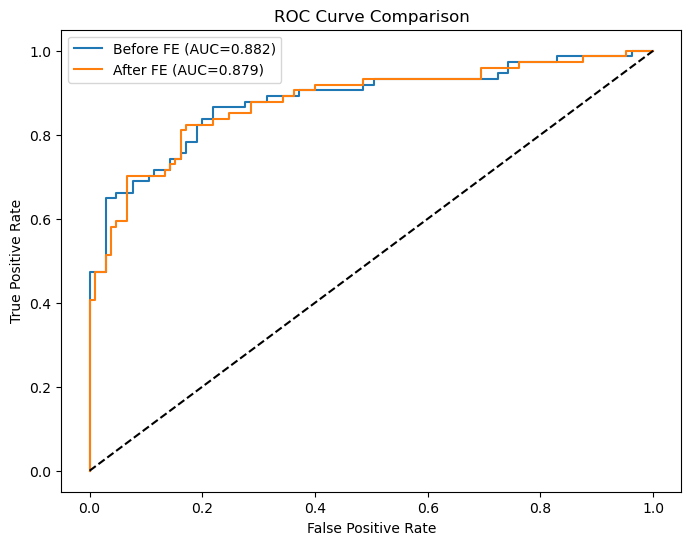

In [81]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

import matplotlib.pyplot as plt

fpr_before,tpr_before,_ = roc_curve(y_test,y_proba_before)
fpr_after,tpr_after,_ = roc_curve(y_test,y_proba_after)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_before,
    tpr_before,
    label=f"Before FE (AUC={roc_auc_score(y_test,y_proba_before):.3f})"
)

plt.plot(
    fpr_after,
    tpr_after,
    label=f"After FE (AUC={roc_auc_score(y_test,y_proba_after):.3f})"
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

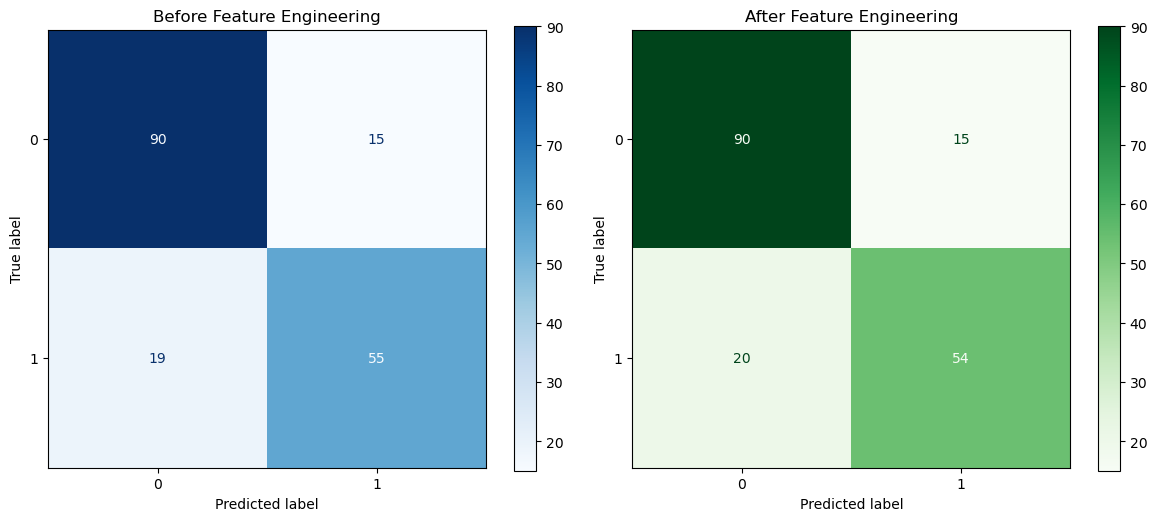

In [82]:
from sklearn.metrics import ConfusionMatrixDisplay

fig,ax = plt.subplots(1,2,figsize=(12,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_before,
    ax=ax[0],
    cmap="Blues"
)

ax[0].set_title("Before Feature Engineering")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_after,
    ax=ax[1],
    cmap="Greens"
)

ax[1].set_title("After Feature Engineering")

plt.tight_layout()

plt.show()

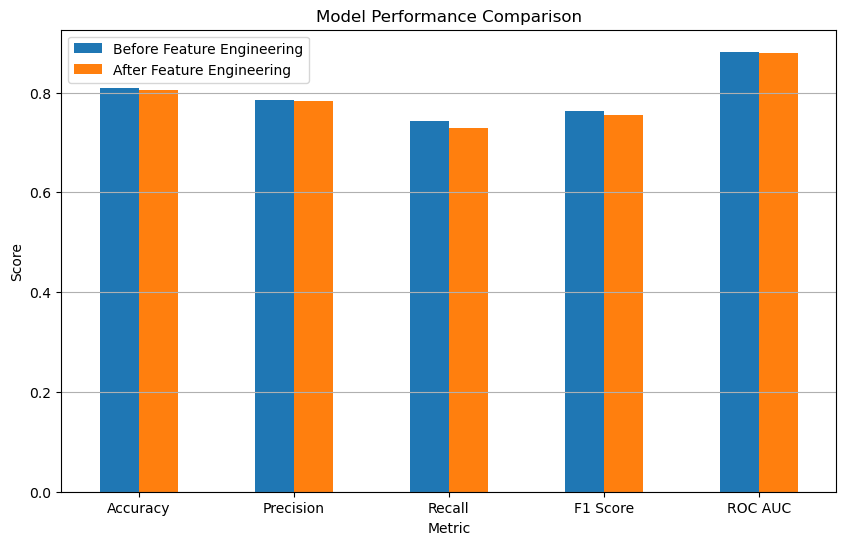

In [83]:
comparison.set_index("Metric").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Performance Comparison")

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.grid(axis="y")

plt.show()

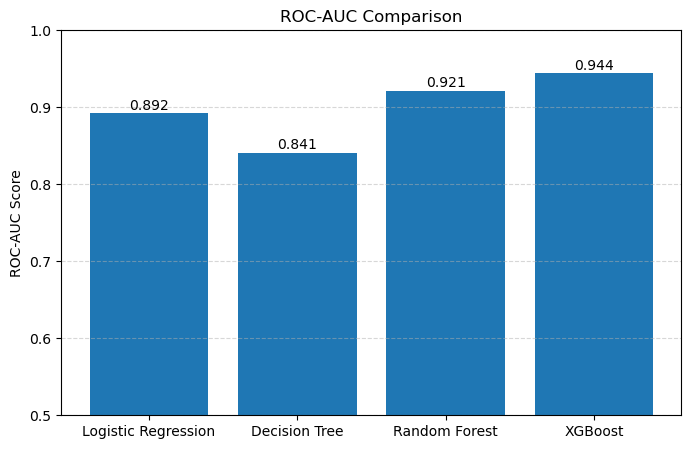

In [84]:
import pandas as pd
import matplotlib.pyplot as plt

auc_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "ROC-AUC": [
        0.892,
        0.841,
        0.921,
        0.944
    ]
})

plt.figure(figsize=(8,5))

bars = plt.bar(
    auc_df["Model"],
    auc_df["ROC-AUC"]
)

plt.title("ROC-AUC Comparison")
plt.ylabel("ROC-AUC Score")
plt.ylim(0.5,1.0)

# Show values on top of each bar
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()+0.005,
        f"{bar.get_height():.3f}",
        ha="center"
    )

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()